## Step 1 — Generate Stratified Annotation Sample

Draws a stratified random sample (~0.6%) from `train_data.csv`, proportional to each product category. Saves to `data/annotation_sample.csv` with an empty `risk_label` column ready for labelling.

In [9]:
import pandas as pd

train_df = pd.read_csv('../data/train_data.csv')

# Stratified sample by product — avoids pandas groupby/apply deprecation in pandas 2.2+
groups = []
for product, group in train_df.groupby('product'):
    groups.append(group.sample(frac=0.006, random_state=42))
sample = pd.concat(groups).reset_index(drop=True)

sample['risk_label'] = ''
sample[['narrative', 'product', 'risk_label']].to_csv(
    '../data/annotation_sample.csv', index=False
)
print(f"Sample size: {len(sample)}")
print(sample['product'].value_counts())

Sample size: 692
product
credit_reporting       304
debt_collection        122
mortgages_and_loans    106
credit_card             83
retail_banking          77
Name: count, dtype: int64


## Step 2 — Auto-Label Complaints (Rule-Based)

Applies a keyword-based decision tree to assign `low`, `medium`, or `high` risk labels, following the criteria in `annotation_guide.md`:
- **HIGH** checked first: FDCPA violations, garnishment, lawsuit, homelessness, identity theft, military/SCRA
- **MEDIUM** checked second: credit denial, harassment, damaged credit score, unresolved disputes, hardship
- **Default**: `medium` for any unlabelled narrative ≥ 10 words (conservative default per guide Section 3); `low` for very short narratives

Saves labelled output to `data/annotation_sample_labelled.csv`.

In [10]:
#annotating using the annotation_guide
import pandas as pd
import re

sample = pd.read_csv('../data/annotation_sample.csv')

HIGH_KEYWORDS = [
    r'\bsued\b', r'\blawsuit\b', r'\blegal action\b', r'\battorney\b', r'\bcourt\b',
    r'\bsummons\b', r'\bgarnish\b', r'\bwage garnishment\b', r'\bbank levy\b',
    r'\bbankruptcy\b', r'\bidentity theft\b', r'\bfraudulent account\b',
    r'\bopened.*account.*name\b', r'\baccount.*opened.*name\b',
    r'\bcannot (pay|afford)\b', r'\bcant (pay|afford)\b',
    r"\bcan't (pay|afford)\b", r'\bunable to (pay|afford)\b', r'\bno money for\b',
    r'\bcannot pay rent\b', r'\bcant pay rent\b', r'\beviction\b',
    r'\bhomeless\b',
    r'\bfdcpa\b', r'\bfair debt collection\b',
    r'\billegal.*collect\b', r'\bcollect.*illegal\b',
    r'\bviolat.*(fdcpa|fair debt|collection act)\b',
    r'\bscra\b', r'\bmilitary\b', r'\bdeployed\b', r'\bveteran\b',
    r'\bfixed income\b', r'\belderly\b', r'\bvulnerable\b',
    r'\bmedication\b.*\bcant afford\b', r'\bfood\b.*\bcant afford\b',
    r'\bmedication\b.*\bcannot afford\b', r'\bfood\b.*\bcannot afford\b',
]

MEDIUM_KEYWORDS = [
    r'\bdenied (mortgage|loan|credit|housing|apartment|rental)\b',  # specific denial only
    r'\bcredit.*(score|rating).*(drop|decreas|damag|hurt|impact|fell)\b',
    r'\b(drop|decreas|damag|hurt|fell).*(credit score|credit rating)\b',
    r'\bscore dropped\b', r'\bdamaged.*credit\b', r'\bdamage.*credit\b',
    r'\baffect.*credit\b', r'\bimpact.*credit\b',
    r'\bharas\b',                                            # harass/harassed/harassment root
    r'\bcalled.*time\b',                                     # repeated calls
    r'\brepeat.*call\b', r'\bcall.*work\b',
    r'\brefused to investigate\b', r'\bno response\b', r'\bignored my dispute\b',
    r'\bmultiple (attempt|complaint|dispute)\b', r'\bunresolved\b',
    r'\bfrustrated\b', r'\bhelpless\b', r'\btrapped\b', r'\bdesperate\b',
    r'\bruining.*life\b',
    r'\blawyer\b',
    r'\bfraud.*account\b', r'\bone.*inquir\b',
    r'\blate fee\b', r'\bpenalt\b', r'\bpenalty interest\b', r'\boverdraft\b',
    r'\bunauthori[sz]ed (account|charge|transaction)\b',
    r'\blost.*apartment\b', r'\bdenied.*housing\b',
    r'\bhardship\b', r'\bfinancial.*difficult\b',
]

# Positive LOW signal — minor admin complaints with no downstream harm
LOW_KEYWORDS = [
    r'\bincorrect address\b', r'\bwrong address\b',
    r'\bduplicate (entry|account|item)\b',
    r'\bwrong balance\b', r'\bincorrect balance\b',
    r'\baccount (still )?(listed|showing|appearing)\b',
    r'\bnever received.{0,20}statement\b',
    r'\bclosed account.{0,30}(showing|reporting|listed)\b',
    r'\bremove.{0,20}(from|off).{0,20}report\b',
    r'\bplease (update|correct|fix|remove)\b',
]

def auto_label(text):
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 'low'
    t = text.lower()
    # HIGH checked first (guide decision tree step 1)
    for pattern in HIGH_KEYWORDS:
        if re.search(pattern, t):
            return 'high'
    # MEDIUM checked second (guide decision tree step 2)
    for pattern in MEDIUM_KEYWORDS:
        if re.search(pattern, t):
            return 'medium'
    # Positive LOW signal — explicit minor admin complaint
    for pattern in LOW_KEYWORDS:
        if re.search(pattern, t):
            return 'low'
    # Default fallback (guide Section 3: unclear → MEDIUM as conservative default)
    # Short narratives (<60 words) with no keyword match are likely routine → LOW
    # Long narratives with no keyword match → MEDIUM (meaningful dispute not captured by keywords)
    word_count = len(t.split())
    return 'medium' if word_count >= 60 else 'low'

sample['risk_label'] = sample['narrative'].apply(auto_label)

print("Label distribution:")
print(sample['risk_label'].value_counts())
print(sample['risk_label'].value_counts(normalize=True).round(3))
print(f"\nTotal: {len(sample)}")

sample.to_csv('../data/annotation_sample_labelled.csv', index=False)
print("\nSaved to data/annotation_sample_labelled.csv")

Label distribution:
risk_label
medium    278
low       253
high      161
Name: count, dtype: int64
risk_label
medium    0.402
low       0.366
high      0.233
Name: proportion, dtype: float64

Total: 692

Saved to data/annotation_sample_labelled.csv


## Step 3 — Train Risk Rating Classifier

Trains a TF-IDF + Logistic Regression classifier on the auto-labelled annotation sample to predict complaint risk level (`low` / `medium` / `high`). Steps: load data → encode labels → train/test split → TF-IDF vectorisation → train → evaluate → save artefacts.

### 3.1 — Load & Inspect Labelled Data

In [17]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

# Load labelled data
df = pd.read_csv('../data/annotation_sample_labelled.csv')
df = df.dropna(subset=['narrative', 'risk_label'])
df = df[df['narrative'].str.strip().str.len() > 0]

print(f"Total labelled samples: {len(df)}")
print("\nLabel distribution:")
print(df['risk_label'].value_counts())


Total labelled samples: 692

Label distribution:
risk_label
medium    278
low       253
high      161
Name: count, dtype: int64


### 3.2 — Encode Labels, Train/Test Split & TF-IDF Vectorisation

Encodes labels with `LabelEncoder`, splits 80/20 (stratified), and vectorises narratives using bigram TF-IDF (max 30,000 features, sublinear TF scaling).

In [18]:
# Encode labels and split
le = LabelEncoder()
y = le.fit_transform(df['risk_label'])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['narrative'].values, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# TF-IDF vectorisation
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=30_000, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Classes: {le.classes_}")


Train: (553, 6657) | Test: (139, 6657)
Classes: ['high' 'low' 'medium']


### 3.3 — Train Logistic Regression Classifier

Trains with `class_weight='balanced'` to compensate for label imbalance. Prints per-class precision, recall, F1, and macro-averaged F1.

In [19]:
# Train Logistic Regression
clf = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs',
                        class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("RISK RATING MODEL — Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

RISK RATING MODEL — Logistic Regression
              precision    recall  f1-score   support

        high       0.88      0.66      0.75        32
         low       0.84      0.61      0.70        51
      medium       0.64      0.89      0.75        56

    accuracy                           0.73       139
   macro avg       0.78      0.72      0.73       139
weighted avg       0.77      0.73      0.73       139

Macro F1: 0.7336


### 3.4 — Evaluate: Confusion Matrix

Plots a normalised confusion matrix and saves it to `outputs/risk_rating_confusion_matrix.png`.

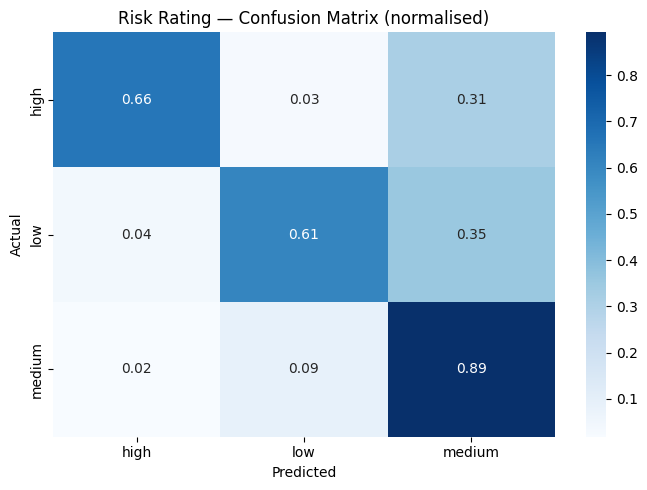

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Risk Rating — Confusion Matrix (normalised)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/risk_rating_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 — Save Model Artefacts & Test Inference

Saves the trained classifier, TF-IDF vectoriser, and label encoder to `outputs/` as pickle files. Runs a quick end-to-end inference example to verify the pipeline works.

In [21]:
# Save model and artefacts
with open('../outputs/risk_rating_model.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open('../outputs/risk_rating_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../outputs/risk_rating_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved to outputs/:")
print("  risk_rating_model.pkl")
print("  risk_rating_tfidf.pkl")
print("  risk_rating_label_encoder.pkl")
print("  risk_rating_confusion_matrix.png")

# Preprocessing helper — must match the pipeline used to build annotation_sample.csv
# (lowercase → tokenise → remove stopwords → lemmatise)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

_stop_words = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [_lemmatizer.lemmatize(t) for t in tokens
              if t.isalpha() and t not in _stop_words]
    return ' '.join(tokens)

def predict_risk(narrative):
    """Predict risk label for a raw (unprocessed) complaint narrative."""
    processed = preprocess(narrative)
    vec = tfidf.transform([processed])
    label = le.inverse_transform(clf.predict(vec))[0]
    probs = clf.predict_proba(vec)[0]
    return label, dict(zip(le.classes_, probs.round(3)))

example = "They opened three credit accounts in my name without my consent and I cannot pay my rent."
label, probs = predict_risk(example)
print(f"\nExample prediction: '{label}'")
print(f"Probabilities: {probs}")

Saved to outputs/:
  risk_rating_model.pkl
  risk_rating_tfidf.pkl
  risk_rating_label_encoder.pkl
  risk_rating_confusion_matrix.png


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>



Example prediction: 'high'
Probabilities: {'high': np.float64(0.503), 'low': np.float64(0.309), 'medium': np.float64(0.187)}


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
